In [1]:
from processing_answers import *

In [2]:
total_df = concat_all_results()
mathe_df = total_df[total_df["language"]=="Mathematica"]
mathe_df

,sequence,complexity,length_type,language,q_length,GPT4_answer,a_length,temperature,real_code,print_code,no_code,explanation,no_sense,exe_out,correct_execution,Levenshtein
0,"2, 4, 6, 8, 10, 12, 14, 16, 18, 20",1,0,Mathematica,173,"```mathematica\nTable[2 i, {i, 1, 10}]\n```",41,1.000,0,0,0,0,0,"2, 4, 6, 8, 10, 12, 14, 16, 18, 20",True,0
1,"3, 6, 9, 12, 15, 18, 21, 24, 27, 30",1,0,Mathematica,174,"```mathematica\nTable[3*n, {n, 1, 10}]\n```",41,1.000,0,0,0,0,0,"3, 6, 9, 12, 15, 18, 21, 24, 27, 30",True,0
2,"4, 8, 12, 16, 20, 24, 28, 32, 36, 40",1,0,Mathematica,175,"```mathematica\nRange[4, 40, 4]\n```",34,1.000,0,0,0,0,0,"4, 8, 12, 16, 20, 24, 28, 32, 36, 40",True,0
3,"5, 10, 15, 20, 25, 30, 35, 40, 45, 50",1,0,Mathematica,176,"```mathematica\nTable[5*i, {i, 1, 10}]\n```",41,1.000,0,0,0,0,0,"5, 10, 15, 20, 25, 30, 35, 40, 45, 50",True,0
4,"6, 12, 18, 24, 30, 36, 42, 48, 54, 60",1,0,Mathematica,176,"```mathematica\nTable[6*i, {i, 1, 10}]\n```",41,1.000,0,0,0,0,0,"6, 12, 18, 24, 30, 36, 42, 48, 54, 60",True,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
585,"187, 218, 260, 295, 301, 314, 379, 410, 452, 469",4,0,Mathematica,186,"```mathematica\nSequence[187, 218, 260, 295, 3...",77,0.001,0,1,0,0,0,Execution error,False,50000
586,"29, 63, 95, 140, 150, 190, 221, 437, 482, 491",4,0,Mathematica,183,"```mathematica\nSequence[29, 63, 95, 140, 150,...",74,0.001,0,1,0,0,0,Execution error,False,50000
587,"3, 11, 84, 144, 156, 177, 188, 199, 229, 284",4,0,Mathematica,182,"```mathematica\nSequence[3, 11, 84, 144, 156, ...",73,0.001,0,1,0,0,0,Execution error,False,50000
588,"26, 94, 98, 137, 176, 301, 323, 330, 372, 444",4,0,Mathematica,183,"```mathematica\nSequence[26, 94, 98, 137, 176,...",74,0.001,0,1,0,0,0,Execution error,False,50000


In [3]:
transformed_mat_df = normalize_prints_and_no_compression_measure(mathe_df)
transformed_mat_df = compress_answers(transformed_mat_df)
transformed_mat_df.columns

Index(['sequence', 'complexity', 'length_type', 'language', 'q_length',
       'GPT4_answer', 'a_length', 'temperature', 'real_code', 'print_code',
       'no_code', 'explanation', 'no_sense', 'exe_out', 'correct_execution',
       'Levenshtein', 'normalized_answer', 'normalized_length',
       'compressed_answer', 'compressed_len', 'compressed_norm_answer',
       'compressed_norm_len', 'compressed_sequence',
       'compressed_sequence_len'],
      dtype='object')

In [4]:
complexity = 3

one_complexity_df = transformed_mat_df[transformed_mat_df["complexity"]==complexity]

avg_answer_len = one_complexity_df.loc[:, "a_length"].mean()
norm_avg_answer_len = one_complexity_df.loc[:, "normalized_length"].mean()
compressed_avg_len = one_complexity_df.loc[:, "compressed_len"].mean()
compressed_norm_avg_len = one_complexity_df.loc[:, "compressed_norm_len"].mean()
compressed_seq_avg_len = one_complexity_df.loc[
    :, "compressed_sequence_len"
].mean()

print("avg_answer_len: ", "%.2f" % (avg_answer_len))
print("norm_avg_answer_len: ", "%.2f" % (norm_avg_answer_len))
print("compressed_avg_len: ", "%.2f" % (compressed_avg_len))
print("compressed_norm_avg_len: ", "%.2f" % (compressed_norm_avg_len))
print("compressed_seq_avg_len: ", "%.2f" % (compressed_seq_avg_len))

avg_answer_len:  64.32
norm_avg_answer_len:  63.32
compressed_avg_len:  131.31
compressed_norm_avg_len:  129.61
compressed_seq_avg_len:  63.07


In [5]:
describe_df(one_complexity_df, 3)

     applying complexity filtering: 
     looking for complexity:  3
      after appply filter:  [3]


('64.32', '63.32', '131.31', '129.61', '63.07')

In [6]:
p_one_complexity_df = transformed_mat_df[(transformed_mat_df["complexity"]==complexity) & (transformed_mat_df["print_code"]==1)]

avg_answer_len = p_one_complexity_df.loc[:, "a_length"].mean()
norm_avg_answer_len = p_one_complexity_df.loc[:, "normalized_length"].mean()
compressed_avg_len = p_one_complexity_df.loc[:, "compressed_len"].mean()
compressed_norm_avg_len = p_one_complexity_df.loc[:, "compressed_norm_len"].mean()
compressed_seq_avg_len = p_one_complexity_df.loc[
    :, "compressed_sequence_len"
].mean()

print("avg_answer_len: ", "%.2f" % (avg_answer_len))
print("norm_avg_answer_len: ", "%.2f" % (norm_avg_answer_len))
print("compressed_avg_len: ", "%.2f" % (compressed_avg_len))
print("compressed_norm_avg_len: ", "%.2f" % (compressed_norm_avg_len))
print("compressed_seq_avg_len: ", "%.2f" % (compressed_seq_avg_len))

avg_answer_len:  58.60
norm_avg_answer_len:  30.60
compressed_avg_len:  120.80
compressed_norm_avg_len:  73.20
compressed_seq_avg_len:  62.00


In [11]:
from statistics import mean

def compute_avg(list_values):
    return mean(list_values)

In [13]:
p_one_complexity_df = transformed_mat_df[(transformed_mat_df["complexity"]==complexity) & (transformed_mat_df["print_code"]==1)]

avg_answer_len = compute_avg(p_one_complexity_df["a_length"].values)
norm_avg_answer_len = compute_avg(p_one_complexity_df["normalized_length"].values)
compressed_avg_len = compute_avg(p_one_complexity_df["compressed_len"].values)
compressed_norm_avg_len = compute_avg(p_one_complexity_df["compressed_norm_len"].values)
compressed_seq_avg_len = compute_avg(p_one_complexity_df["compressed_sequence_len"].values)

print("avg_answer_len: ", "%.2f" % (avg_answer_len))
print("norm_avg_answer_len: ", "%.2f" % (norm_avg_answer_len))
print("compressed_avg_len: ", "%.2f" % (compressed_avg_len))
print("compressed_norm_avg_len: ", "%.2f" % (compressed_norm_avg_len))
print("compressed_seq_avg_len: ", "%.2f" % (compressed_seq_avg_len))

avg_answer_len:  58.00
norm_avg_answer_len:  30.00
compressed_avg_len:  120.00
compressed_norm_avg_len:  73.00
compressed_seq_avg_len:  62.00


In [14]:
p_one_complexity_df

,sequence,complexity,length_type,language,q_length,GPT4_answer,a_length,temperature,real_code,print_code,...,correct_execution,Levenshtein,normalized_answer,normalized_length,compressed_answer,compressed_len,compressed_norm_answer,compressed_norm_len,compressed_sequence,compressed_sequence_len
321,"1, 4, 2, 1, 3, 5, 9, 2, 6, 5",3,0,Mathematica,167,"```mathematica\nSequence[1, 4, 2, 1, 3, 5, 9, ...",57,1.000,0,1,...,False,50000,```mathematica\nSequence[]\n```,29,789c4b4848c84d2cc948051299c9895cc1a985a5a979c9...,116,789c4b4848c84d2cc948051299c9895cc1a985a5a979c9...,70,789c33d45130d15130d25130d45130d65130d551b00473...,62
350,"1, 7, 3, 2, 0, 5, 0, 7, 9, 8",3,0,Mathematica,167,"```mathematica\nsequence = {1, 7, 3, 2, 0, 5, ...",61,0.700,0,1,...,False,28,```mathematica\nsequence = {};\n```,33,789c4b4848c84d2cc948051299c9895cc5a985a5a979c9...,126,789c4b4848c84d2cc948051299c9895cc5a985a5a979c9...,78,789c33d45130d75130d65130d25130d05130059340114b...,62
378,"1, 7, 3, 2, 0, 5, 0, 7, 9, 8",3,0,Mathematica,167,"```mathematica\nSequence @@ {1, 7, 3, 2, 0, 5,...",61,0.500,0,1,...,False,50000,```mathematica\nSequence @@ {}\n```,33,789c4b4848c84d2cc948051299c9895cc1a985a5a979c9...,126,789c4b4848c84d2cc948051299c9895cc1a985a5a979c9...,78,789c33d45130d75130d65130d25130d05130059340114b...,62
406,"1, 7, 3, 2, 0, 5, 0, 7, 9, 8",3,0,Mathematica,167,"```mathematica\nSequence[1, 7, 3, 2, 0, 5, 0, ...",57,0.200,0,1,...,False,50000,```mathematica\nSequence[]\n```,29,789c4b4848c84d2cc948051299c9895cc1a985a5a979c9...,118,789c4b4848c84d2cc948051299c9895cc1a985a5a979c9...,70,789c33d45130d75130d65130d25130d05130059340114b...,62
434,"1, 7, 3, 2, 0, 5, 0, 7, 9, 8",3,0,Mathematica,167,"```mathematica\nSequence[1, 7, 3, 2, 0, 5, 0, ...",57,0.001,0,1,...,False,50000,```mathematica\nSequence[]\n```,29,789c4b4848c84d2cc948051299c9895cc1a985a5a979c9...,118,789c4b4848c84d2cc948051299c9895cc1a985a5a979c9...,70,789c33d45130d75130d65130d25130d05130059340114b...,62


In [7]:
transformed_mat_df.to_csv("testing_statistics.csv", index=False)

In [8]:
one_complexity_df.to_csv("one_complexity_df.csv", index=False)

In [15]:
total_df

,sequence,complexity,length_type,language,q_length,GPT4_answer,a_length,temperature,real_code,print_code,no_code,explanation,no_sense,exe_out,correct_execution,Levenshtein
0,"2, 4, 6, 8, 10, 12, 14, 16, 18, 20",1,0,Mathematica,173,"```mathematica\nTable[2 i, {i, 1, 10}]\n```",41,1.000,0,0,0,0,0,"2, 4, 6, 8, 10, 12, 14, 16, 18, 20",True,0
1,"3, 6, 9, 12, 15, 18, 21, 24, 27, 30",1,0,Mathematica,174,"```mathematica\nTable[3*n, {n, 1, 10}]\n```",41,1.000,0,0,0,0,0,"3, 6, 9, 12, 15, 18, 21, 24, 27, 30",True,0
2,"4, 8, 12, 16, 20, 24, 28, 32, 36, 40",1,0,Mathematica,175,"```mathematica\nRange[4, 40, 4]\n```",34,1.000,0,0,0,0,0,"4, 8, 12, 16, 20, 24, 28, 32, 36, 40",True,0
3,"5, 10, 15, 20, 25, 30, 35, 40, 45, 50",1,0,Mathematica,176,"```mathematica\nTable[5*i, {i, 1, 10}]\n```",41,1.000,0,0,0,0,0,"5, 10, 15, 20, 25, 30, 35, 40, 45, 50",True,0
4,"6, 12, 18, 24, 30, 36, 42, 48, 54, 60",1,0,Mathematica,176,"```mathematica\nTable[6*i, {i, 1, 10}]\n```",41,1.000,0,0,0,0,0,"6, 12, 18, 24, 30, 36, 42, 48, 54, 60",True,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
585,"187, 218, 260, 295, 301, 314, 379, 410, 452, 469",4,0,R,176,"```r\nseq <- c(187, 218, 260, 295, 301, 314, 3...",78,0.001,0,1,0,0,0,"187, 218, 260, 295, 301, 314, 379, 410, 452, 469",True,0
586,"29, 63, 95, 140, 150, 190, 221, 437, 482, 491",4,0,R,173,"```r\nsequence <- c(29, 63, 95, 140, 150, 190,...",85,0.001,0,1,0,0,0,"29, 63, 95, 140, 150, 190, 221, 437, 482, 491",True,0
587,"3, 11, 84, 144, 156, 177, 188, 199, 229, 284",4,0,R,172,"```r\nsequence <- c(3, 11, 84, 144, 156, 177, ...",84,0.001,0,1,0,0,0,", 3, 11, 84, 144, 156, 177, 188, 199, 229, 284",False,2
588,"26, 94, 98, 137, 176, 301, 323, 330, 372, 444",4,0,R,173,"```r\nsequence <- c(26, 94, 98, 137, 176, 301,...",85,0.001,0,1,0,0,0,"26, 94, 98, 137, 176, 301, 323, 330, 372, 444",True,0


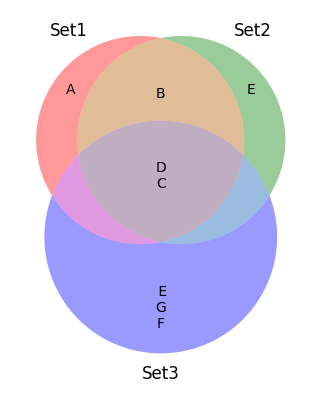

In [21]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

set1 = set(['A', 'B', 'C', 'D'])
set2 = set(['B', 'C', 'D', 'E'])
set3 = set(['C', 'D',' E', 'F', 'G'])

venn = venn3([set1, set2, set3], ('Set1', 'Set2', 'Set3'))

venn.get_label_by_id('100').set_text('\n'.join(set1-set2-set3))
venn.get_label_by_id('110').set_text('\n'.join(set1&set2-set3))
venn.get_label_by_id('010').set_text('\n'.join(set2-set3-set1))
venn.get_label_by_id('101').set_text('\n'.join(set1&set3-set2))
venn.get_label_by_id('111').set_text('\n'.join(set1&set2&set3))
venn.get_label_by_id('011').set_text('\n'.join(set2&set3-set1))
venn.get_label_by_id('001').set_text('\n'.join(set3-set2-set1))

plt.show()

In [23]:
languages_list = list(total_df["language"].unique())
languages_list

['Mathematica', 'Matlab', 'Python', 'ArnoldC', 'JavaScript', 'C++', 'R']

In [24]:
import copy

In [40]:
def list_of_correct_sequences(language, dataframe):
    df = copy.deepcopy(dataframe[dataframe["language"] == language])
    filtered = df[df["correct_execution"] == True]
    return set(list(filtered["sequence"].unique()))

In [41]:
print(list_of_correct_sequences("Matlab",total_df))

{'41, 42, 43, 44, 45, 46, 47, 48, 49, 50', '12, 36, 96, 119, 171, 213, 221, 232, 363, 451', '7, 11, 13, 17, 19, 23, 29, 31, 37, 41', '31, 32, 33, 34, 35, 36, 37, 38, 39, 40', '1, 1, 2, 3, 5, 8, 13, 21, 34, 55', '191, 192, 193, 194, 195, 196, 197, 198, 199, 200', '23, 93, 142, 145, 245, 266, 296, 317, 428, 495', '2, 3, 5, 7, 11, 13, 17, 19, 23, 29', '8, 11, 12, 103, 116, 196, 247, 254, 389, 427', '91, 92, 93, 94, 95, 96, 97, 98, 99, 100', '16, 119, 121, 123, 135, 139, 285, 311, 409, 412', '3, 6, 9, 12, 15, 18, 21, 24, 27, 30', '5, 10, 15, 20, 25, 30, 35, 40, 45, 50', '38, 91, 142, 197, 215, 313, 316, 319, 423, 466', '61, 62, 63, 64, 65, 66, 67, 68, 69, 70', '27, 101, 105, 164, 245, 290, 304, 441, 449, 490', '131, 132, 133, 134, 135, 136, 137, 138, 139, 140', '8, 16, 24, 32, 40, 48, 56, 64, 72, 80', '71, 72, 73, 74, 75, 76, 77, 78, 79, 80', '121, 122, 123, 124, 125, 126, 127, 128, 129, 130', '1, 3, 5, 7, 9, 11, 13, 15, 17, 19', '24, 26, 36, 40, 184, 226, 244, 384, 391, 423', '21, 22, 23,

In [42]:

mathe_list = list_of_correct_sequences("Mathematica", total_df)
R_list = list_of_correct_sequences("R", total_df)
mat_list = list_of_correct_sequences("Matlab", total_df)
python_list = list_of_correct_sequences("Python", total_df)
cpp_list = list_of_correct_sequences("C++", total_df)
arnold_list = list_of_correct_sequences("ArnoldC", total_df)
java_list = list_of_correct_sequences("JavaScript", total_df)

    

In [43]:
from supervenn import supervenn
sets = [mathe_list, R_list, mat_list, python_list, cpp_list, java_list, arnold_list]

In [44]:
# letters = {'a', 'r', 'c', 'i', 'z'}
# programming_languages = {'python', 'r', 'c', 'c++', 'java', 'julia'}
# animals = {'python', 'buffalo', 'turkey', 'cat', 'dog', 'robin'}
# geographic_places = {'java', 'buffalo', 'turkey', 'moscow'}
# names = {'robin', 'julia', 'alice', 'bob', 'conrad'}
# green_things = {'python', 'grass'}
# sets = [letters, programming_languages, animals, geographic_places, names, green_things]
# labels = ['letters', 'programming languages', 'animals', 'geographic places',
#           'human names', 'green things']
# plt.figure(figsize=(10, 6))
# supervenn(sets, labels , sets_ordering='minimize gaps')

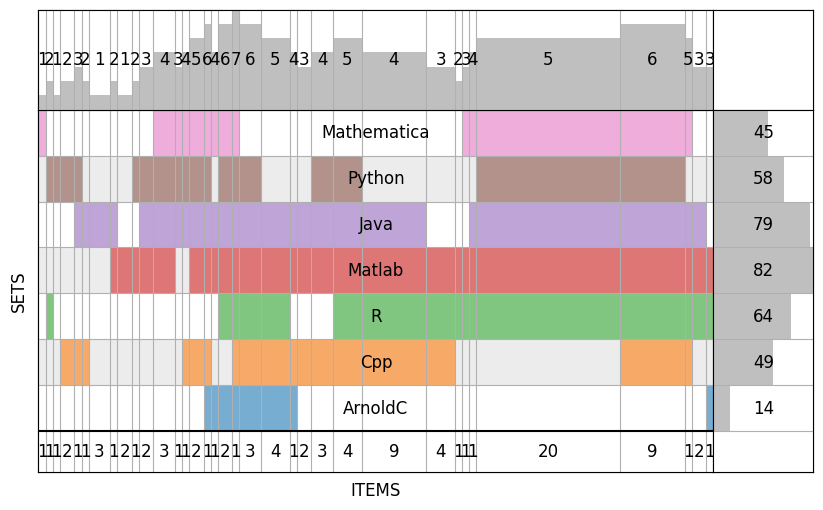

In [45]:

sets = [mathe_list, R_list, mat_list, python_list, cpp_list, java_list, arnold_list]
labels = ['Mathematica', 'R', 'Matlab', 'Python', 'Cpp', 'Java', 'ArnoldC']
plt.figure(figsize=(10, 6))
supervenn(sets, labels , sets_ordering='minimize gaps')

In [46]:
from matplotlib_venn import venn3
set_1 = {1, 2, 3, 4}
set_2 = {3, 4, 5}
set_3 = set_1 ^ set_2
venn3(sets, alpha=0.8)

TypeError: bad operand type for abs(): 'set'